In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('DataSets/D88/iris.csv')

In [3]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
from sklearn.preprocessing import LabelEncoder

In [5]:
encoder = LabelEncoder()

In [6]:
df['species'] = encoder.fit_transform(df['species'])

In [7]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [9]:
df = df[df['species'] != 0][['sepal_width','petal_length','species']]

In [10]:
df.head()

,sepal_width,petal_length,species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

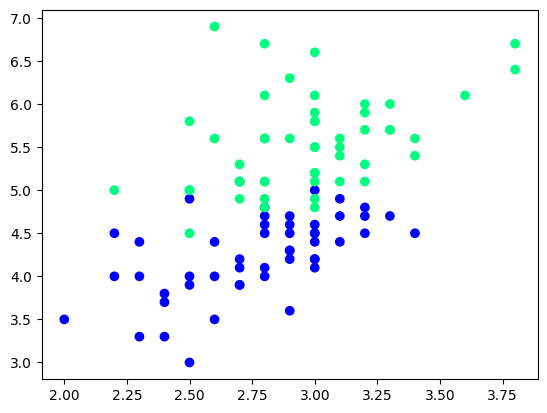

In [12]:
plt.scatter(df['sepal_width'],df['petal_length'],c=df['species'],cmap='winter')

In [13]:
df_train = df.iloc[:60,:].sample(10)
df_train

,sepal_width,petal_length,species
84,3.0,4.5,1
71,2.8,4.0,1
76,2.8,4.8,1
64,2.9,3.6,1
62,2.2,4.0,1
73,2.8,4.7,1
75,3.0,4.4,1
92,2.6,4.0,1
103,2.9,5.6,2
89,2.5,4.0,1


In [14]:
# Taking only 10 rows for training
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [15]:
df_train

,sepal_width,petal_length,species
71,2.8,4.0,1
80,2.4,3.8,1
134,2.6,5.6,2
102,3.0,5.9,2
50,3.2,4.7,1
94,2.7,4.2,1
68,2.2,4.5,1
86,3.1,4.7,1
104,3.0,5.8,2
111,2.7,5.3,2


In [16]:
df_val

,sepal_width,petal_length,species
119,2.2,5.0,2
58,2.9,4.6,1
133,2.8,5.1,2
143,3.2,5.9,2
130,2.8,6.1,2


In [17]:
df_test

,sepal_width,petal_length,species
64,2.9,3.6,1
129,3.0,5.8,2
52,3.1,4.9,1
99,2.8,4.1,1
100,3.3,6.0,2


In [18]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

# Case 1 - Bagging

In [19]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,sepal_width,petal_length,species
68,2.2,4.5,1
80,2.4,3.8,1
68,2.2,4.5,1
50,3.2,4.7,1
104,3.0,5.8,2
80,2.4,3.8,1
94,2.7,4.2,1
94,2.7,4.2,1


In [20]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [21]:
dt_bag1 = DecisionTreeClassifier()

In [24]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))
    

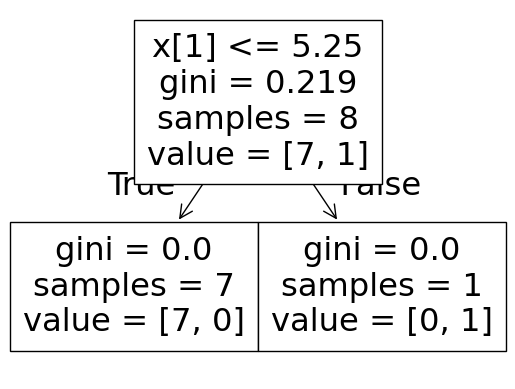

C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.6


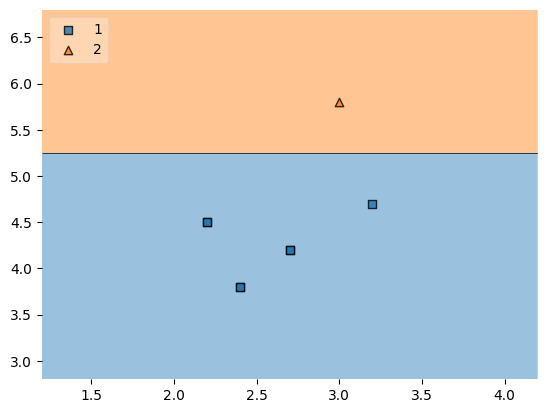

In [25]:
evaluate(dt_bag1, X, y)

In [27]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,sepal_width,petal_length,species
104,3.0,5.8,2
80,2.4,3.8,1
71,2.8,4.0,1
102,3.0,5.9,2
111,2.7,5.3,2
80,2.4,3.8,1
71,2.8,4.0,1
104,3.0,5.8,2


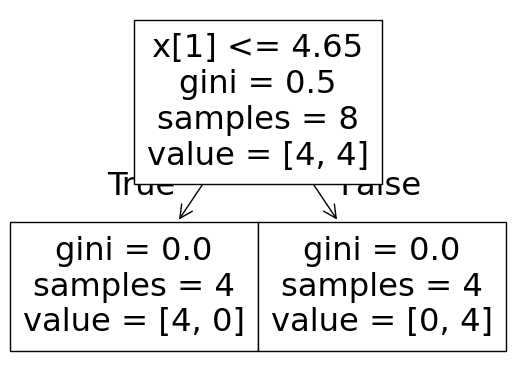

C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


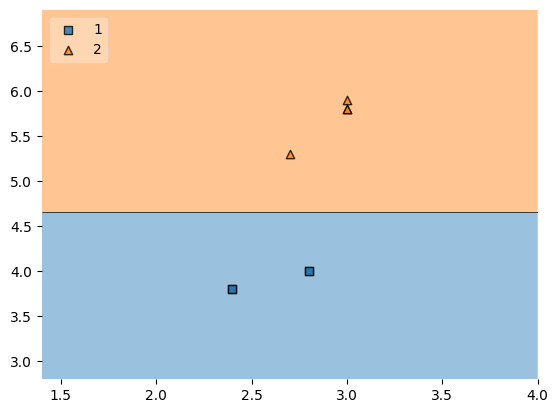

In [28]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [29]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,sepal_width,petal_length,species
80,2.4,3.8,1
86,3.1,4.7,1
50,3.2,4.7,1
71,2.8,4.0,1
111,2.7,5.3,2
94,2.7,4.2,1
104,3.0,5.8,2
68,2.2,4.5,1


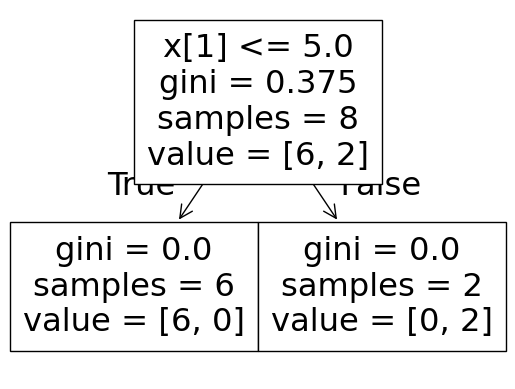

C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.8


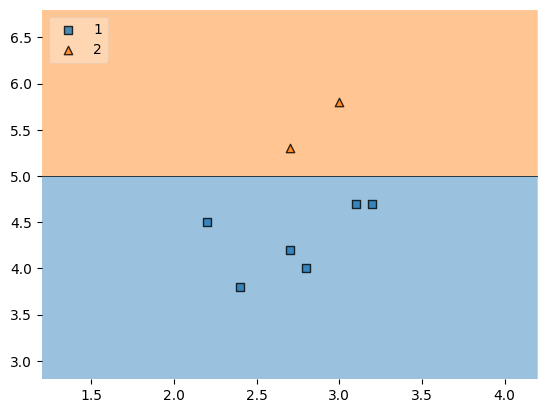

In [30]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

In [31]:
print("Predictor 1",dt_bag1.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([2.2,5.0]).reshape(1,2)))

Predictor 1 [1]
Predictor 2 [2]
Predictor 3 [1]


C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


# Pasting

In [32]:
# Row sampling without replacement
df_train

,sepal_width,petal_length,species
71,2.8,4.0,1
80,2.4,3.8,1
134,2.6,5.6,2
102,3.0,5.9,2
50,3.2,4.7,1
94,2.7,4.2,1
68,2.2,4.5,1
86,3.1,4.7,1
104,3.0,5.8,2
111,2.7,5.3,2


In [33]:
df_train.sample(8)

,sepal_width,petal_length,species
71,2.8,4.0,1
80,2.4,3.8,1
104,3.0,5.8,2
102,3.0,5.9,2
50,3.2,4.7,1
94,2.7,4.2,1
111,2.7,5.3,2
68,2.2,4.5,1


# Random Subspaces

In [34]:
df1 = pd.read_csv('DataSets/D88/iris.csv')
df1 = df1.sample(10)

In [35]:
df1

,sepal_length,sepal_width,petal_length,petal_width,species
9,4.9,3.1,1.5,0.1,setosa
128,6.4,2.8,5.6,2.1,virginica
45,4.8,3.0,1.4,0.3,setosa
134,6.1,2.6,5.6,1.4,virginica
138,6.0,3.0,4.8,1.8,virginica
106,4.9,2.5,4.5,1.7,virginica
93,5.0,2.3,3.3,1.0,versicolor
123,6.3,2.7,4.9,1.8,virginica
115,6.4,3.2,5.3,2.3,virginica
51,6.4,3.2,4.5,1.5,versicolor


In [36]:
df1.sample(2,replace=True,axis=1)

,sepal_length,petal_length
9,4.9,1.5
128,6.4,5.6
45,4.8,1.4
134,6.1,5.6
138,6.0,4.8
106,4.9,4.5
93,5.0,3.3
123,6.3,4.9
115,6.4,5.3
51,6.4,4.5


# Random Patches

In [37]:
df1

,sepal_length,sepal_width,petal_length,petal_width,species
9,4.9,3.1,1.5,0.1,setosa
128,6.4,2.8,5.6,2.1,virginica
45,4.8,3.0,1.4,0.3,setosa
134,6.1,2.6,5.6,1.4,virginica
138,6.0,3.0,4.8,1.8,virginica
106,4.9,2.5,4.5,1.7,virginica
93,5.0,2.3,3.3,1.0,versicolor
123,6.3,2.7,4.9,1.8,virginica
115,6.4,3.2,5.3,2.3,virginica
51,6.4,3.2,4.5,1.5,versicolor


In [38]:
df1.sample(8,replace=True).sample(2,replace=True,axis=1)

,species,species
138,virginica,virginica
45,setosa,setosa
45,setosa,setosa
9,setosa,setosa
45,setosa,setosa
93,versicolor,versicolor
9,setosa,setosa
93,versicolor,versicolor
